In [15]:
# ============================================================
# NOTEBOOK — PHASE 4 : Visualisation & Communication + ALERTES
# Tunis (2010–2024)
# Objectifs :
# 1) Produire des graphiques clairs (climat + performance modèle)
# 2) Interpréter les résultats (tendances + erreurs)
# 3) Synthétiser des insights actionnables
# 4) Ajouter un système d'ALERTES automatiques (événements extrêmes)
# ============================================================

# -----------------------------
# Imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Config affichage
# -----------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# -----------------------------
# Fichiers
# -----------------------------
FEAT_PATH  = "tunis_2010_2024_clean_features.csv"           # dataset features (Phase 1)
MODEL_PATH = "best_model_t2mmax_nextday_2010_2024.pkl"      # modèle entraîné (Phase 3)

# -----------------------------
# Paramètres split (doit être IDENTIQUE à Phase 3)
# -----------------------------
TRAIN_RATIO = 0.8

# ============================================================
# Logger + utils
# ============================================================

def log_ok(msg):   print(f"✅ {msg}")
def log_warn(msg): print(f"⚠️ {msg}")
def log_err(msg):  print(f"❌ {msg}")

def assert_file_exists(path: str):
    # Vérifie l'existence du fichier
    if not Path(path).exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")

def safe_read_csv(path: str, parse_dates=None):
    # Lecture robuste contre problèmes d'encodage
    assert_file_exists(path)
    try:
        return pd.read_csv(path, parse_dates=parse_dates, encoding="utf-8-sig")
    except UnicodeDecodeError:
        log_warn("UnicodeDecodeError -> fallback latin-1")
        return pd.read_csv(path, parse_dates=parse_dates, encoding="latin-1")

def require_columns(df: pd.DataFrame, cols: list, context: str):
    # Vérifie les colonnes indispensables
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{context} : colonnes manquantes -> {missing}")


In [17]:
# ============================================================
# 4.A ALERTES : Détection d’événements extrêmes (observés)
# ============================================================

# --- Seuils d'alerte (tu peux les ajuster et les justifier dans le rapport) ---
TH_HEAT   = 40.0  # °C : canicule (ex : >= 40)
TH_RAIN   = 30.0  # mm/jour : pluie extrême
TH_WIND   = 12.0  # m/s : vent fort
TH_FREEZE = 0.0   # °C : gel (Tmin < 0)

def detect_extreme_events(df: pd.DataFrame) -> pd.DataFrame:
    """
    Détecte des événements extrêmes sur les données OBSERVÉES.
    Retourne un DataFrame d'alertes : date, type_alerte, valeur, seuil.
    """
    alerts = []

    # --- Canicule ---
    if "T2M_MAX" in df.columns:
        mask = df["T2M_MAX"] >= TH_HEAT
        for _, r in df.loc[mask, ["date", "T2M_MAX"]].iterrows():
            alerts.append({
                "date": r["date"],
                "type_alerte": "Canicule",
                "valeur": float(r["T2M_MAX"]),
                "seuil": TH_HEAT
            })

    # --- Pluie extrême ---
    if "PRECTOTCORR" in df.columns:
        mask = df["PRECTOTCORR"] >= TH_RAIN
        for _, r in df.loc[mask, ["date", "PRECTOTCORR"]].iterrows():
            alerts.append({
                "date": r["date"],
                "type_alerte": "Pluie extrême",
                "valeur": float(r["PRECTOTCORR"]),
                "seuil": TH_RAIN
            })

    # --- Vent fort ---
    if "WS2M" in df.columns:
        mask = df["WS2M"] >= TH_WIND
        for _, r in df.loc[mask, ["date", "WS2M"]].iterrows():
            alerts.append({
                "date": r["date"],
                "type_alerte": "Vent fort",
                "valeur": float(r["WS2M"]),
                "seuil": TH_WIND
            })

    # --- Gel ---
    if "T2M_MIN" in df.columns:
        mask = df["T2M_MIN"] < TH_FREEZE
        for _, r in df.loc[mask, ["date", "T2M_MIN"]].iterrows():
            alerts.append({
                "date": r["date"],
                "type_alerte": "Gel",
                "valeur": float(r["T2M_MIN"]),
                "seuil": TH_FREEZE
            })

    alerts_df = pd.DataFrame(alerts)

    # Trier par date si non vide
    if not alerts_df.empty:
        alerts_df = alerts_df.sort_values("date").reset_index(drop=True)

    return alerts_df

def plot_alerts_per_year(alerts_df: pd.DataFrame):
    # Graphique : nombre d'alertes par année (communication claire)
    if alerts_df.empty:
        log_ok("Aucune alerte -> plot alertes/an ignoré")
        return

    tmp = alerts_df.copy()
    tmp["annee"] = pd.to_datetime(tmp["date"]).dt.year
    counts = tmp.groupby(["annee", "type_alerte"]).size().unstack(fill_value=0)

    plt.figure(figsize=(10, 4))
    for col in counts.columns:
        plt.plot(counts.index, counts[col], label=col)
    plt.title("Nombre d'alertes par année")
    plt.xlabel("Année")
    plt.ylabel("Nombre d'alertes")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [19]:
# ============================================================
# 4.1 Graphiques climat : tendances mensuelles + distributions
# ============================================================

def plot_monthly_mean(df, col, title, ylabel):
    # Trace la moyenne mensuelle pour visualiser les tendances/saisons
    if col not in df.columns:
        log_warn(f"{col} absent -> plot ignoré")
        return

    monthly = df.set_index("date")[col].resample("M").mean()

    plt.figure()
    plt.plot(monthly.index, monthly.values)
    plt.title(title)
    plt.xlabel("Date (mensuel)")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_box_by_month(df, col, title, ylabel):
    # Boxplot par mois : montre la variabilité saisonnière
    if col not in df.columns:
        log_warn(f"{col} absent -> boxplot ignoré")
        return

    tmp = df.copy()
    tmp["mois"] = tmp["date"].dt.month
    data = [tmp[tmp["mois"] == m][col].dropna().values for m in range(1, 13)]

    plt.figure()
    plt.boxplot(data, labels=list(range(1, 13)))
    plt.title(title)
    plt.xlabel("Mois")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_yearly_trend(df, col, title, ylabel, agg="mean"):
    # Comparaison annuelle entre années
    if col not in df.columns:
        log_warn(f"{col} absent -> yearly trend ignoré")
        return

    tmp = df.copy()
    tmp["annee"] = tmp["date"].dt.year

    if agg == "mean":
        year = tmp.groupby("annee")[col].mean()
    elif agg == "sum":
        year = tmp.groupby("annee")[col].sum()
    else:
        raise ValueError("agg doit être 'mean' ou 'sum'")

    plt.figure()
    plt.plot(year.index, year.values)
    plt.title(title)
    plt.xlabel("Année")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


In [21]:
# ============================================================
# 4.2 Partie modèle : reconstruire y_next + split + évaluer
# ============================================================

def build_nextday_target(df: pd.DataFrame) -> pd.DataFrame:
    # Construit la cible "lendemain" comme en Phase 3
    require_columns(df, ["T2M_MAX"], "build_nextday_target")
    df = df.copy()
    df["y_next"] = df["T2M_MAX"].shift(-1)  # <-- cible lendemain
    df = df.dropna(subset=["y_next"]).reset_index(drop=True)
    return df

def build_ml_matrices(df: pd.DataFrame):
    # Construit X et y (identique à Phase 3)
    require_columns(df, ["date", "T2M_MAX", "y_next"], "build_ml_matrices")

    X = df.drop(columns=["date", "T2M_MAX", "y_next"], errors="ignore").copy()
    y = df["y_next"].astype(float).copy()

    # Retirer colonnes techniques si présentes
    for c in ["YEAR", "MO", "DY", "DOY", "PS"]:
        if c in X.columns:
            X = X.drop(columns=[c])

    return X, y

def split_time(df: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    # Split temporel (identique Phase 3)
    split_idx = int(len(df) * TRAIN_RATIO)
    X_test  = X.iloc[split_idx:].copy()
    y_test  = y.iloc[split_idx:].copy()
    dates_test = df["date"].iloc[split_idx:].copy()
    return X_test, y_test, dates_test

def compute_metrics(y_true, y_pred):
    # Calcule MAE / RMSE / R²
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


✅ Dataset chargé : (5479, 21) | 2010-01-01 00:00:00 -> 2024-12-31 00:00:00
⚠️ 117 alertes détectées sur toute la période.


,date,type_alerte,valeur,seuil
0,2010-07-14,Canicule,41.67,40.0
1,2010-07-22,Canicule,40.65,40.0
2,2010-08-20,Canicule,41.53,40.0
3,2010-11-04,Pluie extrême,33.26,30.0
4,2011-07-13,Canicule,40.72,40.0
5,2011-07-17,Canicule,40.15,40.0
6,2011-09-01,Canicule,40.52,40.0
7,2011-09-02,Canicule,41.84,40.0
8,2011-10-30,Pluie extrême,31.21,30.0
9,2012-02-22,Pluie extrême,35.09,30.0


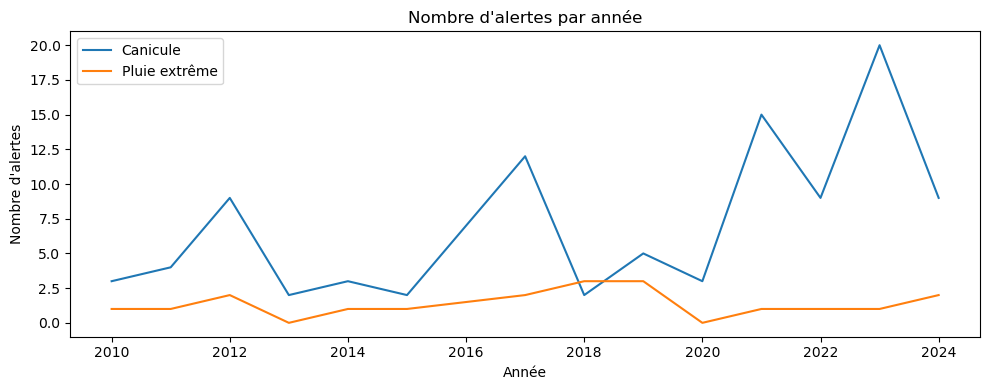

C:\Users\guerf\AppData\Local\Temp\ipykernel_14156\140461280.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index("date")[col].resample("M").mean()


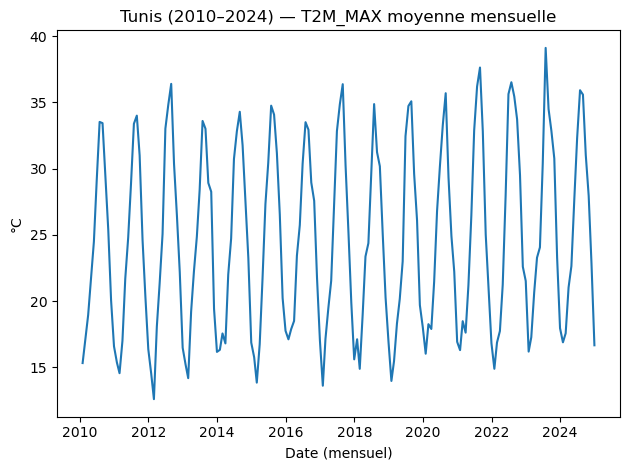

C:\Users\guerf\AppData\Local\Temp\ipykernel_14156\140461280.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=list(range(1, 13)))


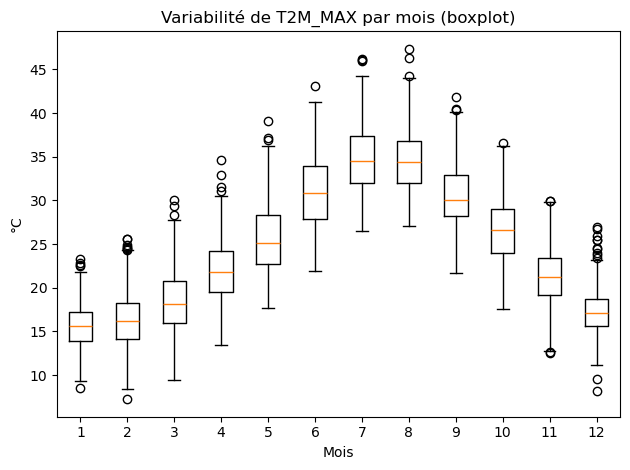

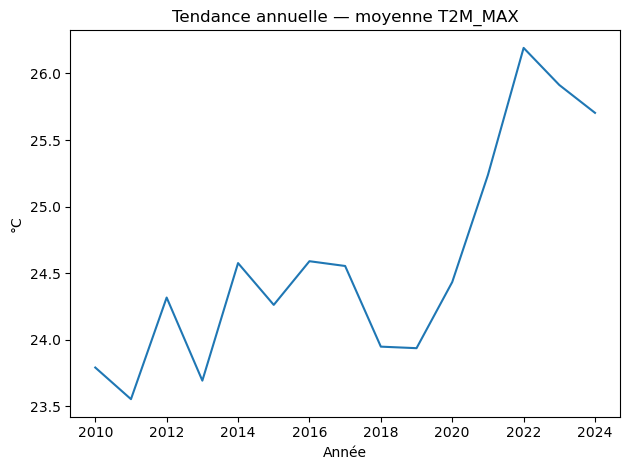

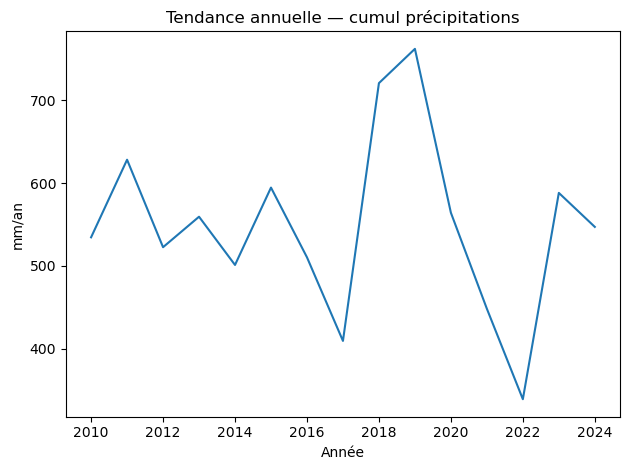

✅ Modèle chargé (Phase 3)
✅ TEST metrics : MAE=1.788 | RMSE=2.362 | R²=0.912


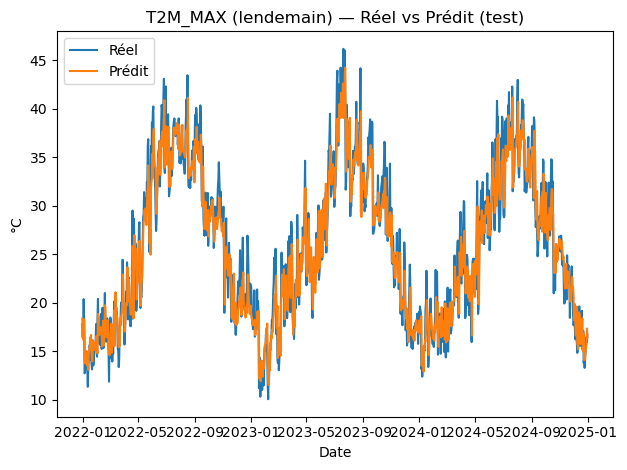

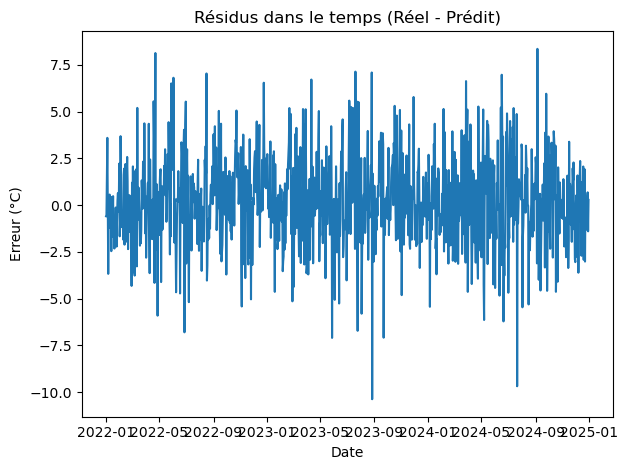

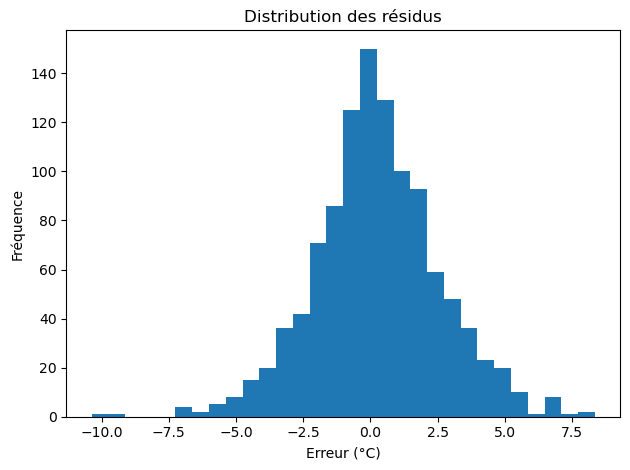

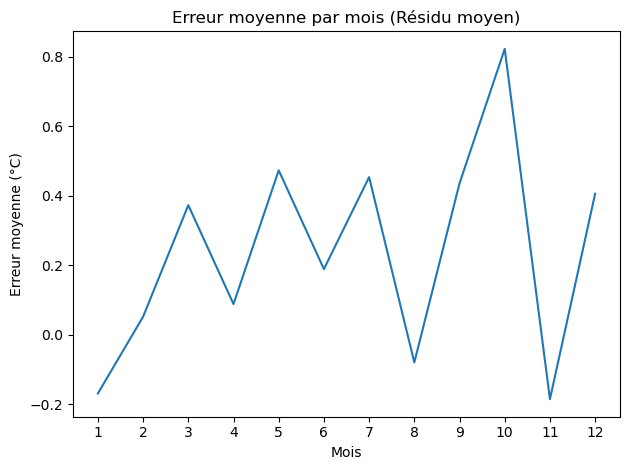


----------------------------------------------------------------------
🔮 Alerte basée sur la prédiction (lendemain du dernier jour) :
Prévision T2M_MAX demain = 16.42 °C
✅ Pas d'alerte canicule demain (selon la prédiction)
----------------------------------------------------------------------

📌 SYNTHÈSE
1) Tendances climatiques :
- La température maximale présente un cycle saisonnier marqué (été/hiver).
- Les précipitations sont très variables avec des épisodes extrêmes ponctuels.

2) Performance du modèle (prédiction de T2M_MAX du lendemain) :
- MAE = 1.79 °C  (erreur absolue moyenne)
- RMSE = 2.36 °C (pénalise davantage les grosses erreurs)
- R² = 0.91      (variance expliquée)

3) Alertes météo (événements extrêmes) :
- Nombre total d’alertes détectées : 117
- Répartition par type :
type_alerte
Canicule         98
Pluie extrême    19

4) Insights actionnables (collectivité) :
- Planifier des actions de prévention lors des vagues de chaleur.
- Surveiller les pluies extrêmes pour ré

In [23]:
# ============================================================
# 4.3 Visualisations performance : réel vs prédit + résidus
# ============================================================

def plot_real_vs_pred(dates, y_true, y_pred, title):
    # Visualise la qualité de prédiction sur la période test
    plt.figure()
    plt.plot(dates, y_true.values, label="Réel")
    plt.plot(dates, y_pred, label="Prédit")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("°C")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_residuals(dates, residuals):
    # Résidus = (réel - prédit), utiles pour détecter biais et périodes difficiles
    plt.figure()
    plt.plot(dates, residuals)
    plt.title("Résidus dans le temps (Réel - Prédit)")
    plt.xlabel("Date")
    plt.ylabel("Erreur (°C)")
    plt.tight_layout()
    plt.show()

    # Histogramme : erreurs centrées autour de 0 ?
    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title("Distribution des résidus")
    plt.xlabel("Erreur (°C)")
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()

def plot_error_by_month(dates, residuals):
    # Erreur moyenne par mois (ex: modèle moins bon en été ?)
    tmp = pd.DataFrame({"date": dates, "residual": residuals})
    tmp["mois"] = tmp["date"].dt.month
    m = tmp.groupby("mois")["residual"].mean()

    plt.figure()
    plt.plot(m.index, m.values)
    plt.title("Erreur moyenne par mois (Résidu moyen)")
    plt.xlabel("Mois")
    plt.ylabel("Erreur moyenne (°C)")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

# ============================================================
# 4.4 Synthèse (texte prêt pour rapport)
# ============================================================

def print_report_synthesis(mae, rmse, r2, alerts_df: pd.DataFrame):
    # Texte court et actionnable (phase communication)
    print("\n" + "="*85)
    print("📌 SYNTHÈSE")
    print("="*85)
    print("1) Tendances climatiques :")
    print("- La température maximale présente un cycle saisonnier marqué (été/hiver).")
    print("- Les précipitations sont très variables avec des épisodes extrêmes ponctuels.")
    print("")
    print("2) Performance du modèle (prédiction de T2M_MAX du lendemain) :")
    print(f"- MAE = {mae:.2f} °C  (erreur absolue moyenne)")
    print(f"- RMSE = {rmse:.2f} °C (pénalise davantage les grosses erreurs)")
    print(f"- R² = {r2:.2f}      (variance expliquée)")
    print("")
    print("3) Alertes météo (événements extrêmes) :")
    if alerts_df.empty:
        print("- Aucune alerte détectée sur la période (selon les seuils choisis).")
    else:
        print(f"- Nombre total d’alertes détectées : {len(alerts_df)}")
        print("- Répartition par type :")
        print(alerts_df["type_alerte"].value_counts().to_string())
    print("")
    print("4) Insights actionnables (collectivité) :")
    print("- Planifier des actions de prévention lors des vagues de chaleur.")
    print("- Surveiller les pluies extrêmes pour réduire les risques d’inondation.")
    print("- Anticiper des épisodes de vent fort (sécurité routière, infrastructures).")
    print("="*85)

# ============================================================
# RUN PHASE 4 : exécution complète (avec alertes)
# ============================================================

def run_phase4():
    try:
        # 1) Charger les données features
        df = safe_read_csv(FEAT_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
        require_columns(df, ["date", "T2M_MAX"], "Phase 4")
        log_ok(f"Dataset chargé : {df.shape} | {df['date'].min()} -> {df['date'].max()}")

        # 2) Calculer les alertes sur TOUTE la période observée
        alerts_all = detect_extreme_events(df)
        if alerts_all.empty:
            log_ok("Aucune alerte extrême sur toute la période (seuils actuels).")
        else:
            log_warn(f"{len(alerts_all)} alertes détectées sur toute la période.")
            display(alerts_all.head(20))

        # 3) Graphique : alertes par année (si alertes existent)
        plot_alerts_per_year(alerts_all)

        # -----------------------------
        # A) Visualisations climat
        # -----------------------------
        plot_monthly_mean(df, "T2M_MAX", "Tunis (2010–2024) — T2M_MAX moyenne mensuelle", "°C")
        plot_box_by_month(df, "T2M_MAX", "Variabilité de T2M_MAX par mois (boxplot)", "°C")
        plot_yearly_trend(df, "T2M_MAX", "Tendance annuelle — moyenne T2M_MAX", "°C", agg="mean")
        plot_yearly_trend(df, "PRECTOTCORR", "Tendance annuelle — cumul précipitations", "mm/an", agg="sum")

        # -----------------------------
        # B) Évaluation du modèle sur test (optionnel si le .pkl existe)
        # -----------------------------
        mae = rmse = r2 = np.nan  # valeurs par défaut si modèle absent

        if Path(MODEL_PATH).exists():
            model = joblib.load(MODEL_PATH)
            log_ok("Modèle chargé (Phase 3)")

            # Reconstruire la cible lendemain
            df2 = build_nextday_target(df)

            # Construire X et y comme en Phase 3
            X, y = build_ml_matrices(df2)

            # Split test
            X_test, y_test, dates_test = split_time(df2, X, y)

            # Prédire
            y_pred = model.predict(X_test)

            # Métriques
            mae, rmse, r2 = compute_metrics(y_test, y_pred)
            log_ok(f"TEST metrics : MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

            # Visualisations performance
            plot_real_vs_pred(dates_test, y_test, y_pred, "T2M_MAX (lendemain) — Réel vs Prédit (test)")
            residuals = y_test.values - y_pred
            plot_residuals(dates_test, residuals)
            plot_error_by_month(dates_test, residuals)

            # -----------------------------
            # C) Option : alerte canicule sur la prédiction du lendemain (dernier jour)
            # -----------------------------
            # Dernière ligne de df2 (dernière date avec features)
            last_row = df2.sort_values("date").iloc[-1:].copy()

            # Construire X_last identique à Phase 3 (retirer date, T2M_MAX, y_next)
            X_last = last_row.drop(columns=["date", "T2M_MAX", "y_next"], errors="ignore")

            # Prédire T2M_MAX du lendemain pour la dernière date
            pred_next = float(model.predict(X_last)[0])

            print("\n" + "-"*70)
            print("🔮 Alerte basée sur la prédiction (lendemain du dernier jour) :")
            print(f"Prévision T2M_MAX demain = {pred_next:.2f} °C")
            if pred_next >= TH_HEAT:
                print("⚠️ ALERTE : risque de CANICULE demain (selon la prédiction)")
            else:
                print("✅ Pas d'alerte canicule demain (selon la prédiction)")
            print("-"*70)

        else:
            log_warn("Modèle .pkl non trouvé : partie performance/prédiction ignorée (Phase 3 requise).")

        # -----------------------------
        # D) Synthèse rapport (inclut alertes)
        # -----------------------------
        print_report_synthesis(mae, rmse, r2, alerts_all)

        log_ok("Phase 4 terminée ✅")

    except Exception as e:
        log_err(f"Phase 4 échouée: {e}")
        raise

# --- Exécution ---
run_phase4()